## Imports and functions

In [1]:
# -------------------------------------------------------------------
# 1) Standard library and environment utilities
# -------------------------------------------------------------------
import os
from datetime import datetime
from math import floor, log

# -------------------------------------------------------------------
# 2) Data / numerical analysis stack
# -------------------------------------------------------------------
import numpy as np
import pandas as pd

# -------------------------------------------------------------------
# 3) Plotting and visualization
# -------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams

# -------------------------------------------------------------------
# 4) Time series and statistics
# -------------------------------------------------------------------
from scipy import signal
from scipy.stats import norm, pearsonr, rankdata
from statsmodels.tsa import seasonal
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, ccf, grangercausalitytests

# -------------------------------------------------------------------
# 5) Machine learning and preprocessing
# -------------------------------------------------------------------
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# -------------------------------------------------------------------
# 6) BigQuery client dependencies (kept for compatibility with existing workflow)
# -------------------------------------------------------------------
# from google.cloud import bigquery, bigquery_storage
from pandas_gbq import to_gbq

# -------------------------------------------------------------------
# 7) Project utilities: move reusable helper functions to analysis_utils.py
# -------------------------------------------------------------------
from analysis_utils import (
    append_csv_to_dataframe,
    adjusted_r2,
    bic,
    ccf_funct,
    cross_correlate,
    detrender,
    dual_plot_corr,
    evaluate_model,
    forward_fill_increment,
    lagged_corr_plot,
    lin_model,
    plot_ccf_2,
    robust_r2_score,
    roll_apply_max_ccf,
    series_rel_plot,
    twinplot,
    LinearModelClass,
)

# Notebook plotting defaults
rcParams['figure.figsize'] = 12, 5

# Common plotting color scheme
color1 = 'black'
color2 = 'grey'
color3 = '#ffcc00'
f = 12 * 1e6

### Intro

In [2]:
directory_path = "C:/Users/illoi/Escritorio-2/00 - RETAIL INSIGHTS & ANALYTICS/01 - MARKET ANALYSIS/Data/US - Copy"
df_file_name = 'prov2.csv'
result_df_file_name = 'prov.csv'
sep = ','

df = pd.read_csv(os.path.join(directory_path, df_file_name), sep=sep, index_col=0, parse_dates=[0])
result_df = pd.read_csv(os.path.join(directory_path, result_df_file_name), sep=sep, index_col=0, parse_dates=[0])
df.head()

,CB CCI,Household PCE,Michigan CSI,PCE Durable goods Furnishings and durable household equipment,PCE,PCEDG PCE Durable goods,PCEDGC96 Real PCE Durable goods Chain-type,PCEPI PCE Chain-type,PCEPILFE PCE Excl Food and Energy Chain-Type,Real Households Final PCE,...,Real Usable Personal Income,Personal Consumption Expenditures per capita,Real Personal Consumption Expenditures per capita,Real Personal Consumption Expenditures per household,Consumption as share of GDP,roll_Consumption as share of GDP,roll_Consumption exp as share of GDP,Retail Sales Furniture & HF corr,Y,Y_infl_adj
1992-01-01,52.5,4109.625,67.5,121.980,4084.7,495.6,NaN,62.638,63.641,1607342.5,...,25967.688136,15.954993,28.278407,75.674101,0.641935,0.642253,0.643000,3699.0,3975.607143,2874.625555
1992-02-01,50.2,4109.625,68.8,121.980,4099.5,501.3,NaN,62.797,63.814,1607342.5,...,25953.929663,16.000568,28.297801,75.783899,0.641548,0.642516,0.643143,3759.0,3992.937500,2880.907287
1992-03-01,47.3,4109.625,76.0,121.980,4117.0,491.7,NaN,62.949,63.973,1607342.5,...,25957.001921,16.059669,28.300232,75.833836,0.642662,0.642504,0.643250,3997.0,4020.301587,2890.224002
1992-04-01,56.5,4109.625,77.2,122.968,4131.5,490.0,NaN,63.119,64.183,1616605.0,...,26001.846848,16.109056,28.326169,75.937146,0.642765,0.642619,0.643333,3981.0,4051.587500,2906.447274
1992-05-01,65.1,4109.625,79.2,122.968,4158.4,501.9,NaN,63.203,64.273,1616605.0,...,25990.949403,16.202541,28.429371,76.267435,0.642879,0.642933,0.643500,4109.0,4078.626263,2919.560675


### Adding the diff columns

In [3]:
original_cols = df.columns

In [4]:
diff_df = pd.DataFrame()
pct_df = pd.DataFrame()
roll_pct_df = pd.DataFrame()

diff_df = df.diff()
pct_df = df.pct_change(fill_method=None)
roll_pct_df = df.pct_change(fill_method=None).rolling(window=12, min_periods=1, center=True).mean()

diff_df.rename(columns=dict(zip(diff_df.columns,'diff_' + diff_df.columns)), inplace=True)
pct_df.rename(columns=dict(zip(pct_df.columns,'pct_chg_' + pct_df.columns)), inplace=True)
roll_pct_df.rename(columns=dict(zip(roll_pct_df.columns,'roll_pct_chg_' + roll_pct_df.columns)), inplace=True)

df = pd.concat([df, diff_df, pct_df, roll_pct_df], axis=1)

## Real Estate market factors

### Interest rates

-0.6753478425270123
0.8457161110672576
-0.418143090882385
-0.49052000955596836
0.6870408707618902
-0.29929683797111223


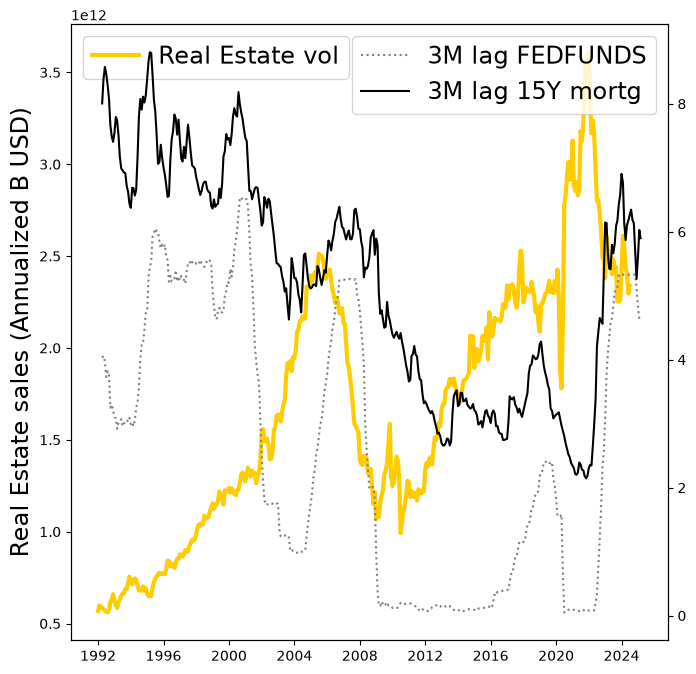

In [5]:
shift = 3

series1 = df['Real Estate - market sales']
series2 = df['MORTGAGE15US'].shift(shift)
series3 = df['FEDFUNDS'].shift(shift)


fig, ax1 = plt.subplots(figsize=(7.7,8))

ax1.plot(series1, color3, linewidth=3, label='Real Estate vol')
ax1.legend(loc='upper left', fontsize=17)
ax1.set_ylabel('Real Estate sales (Annualized B USD)', fontsize=17)
# ax1.set_ylim([80,120])

ax2 = ax1.twinx()

ax2.plot(series3, color2, linestyle=':',  label='{s}M lag FEDFUNDS'.format(s=shift))
ax2.plot(series2, color1, label='{s}M lag 15Y mortg'.format(s=shift))
ax2.legend(loc='upper right', fontsize=17)
# ax2.set_ylabel('Interest (%)', fontsize=17)

bool_filter = series1.dropna().index.intersection(series3.dropna().index)


rpc_series1 = series1.pct_change(fill_method=None).rolling(window=12, min_periods=1, center=True).mean()
rpc_series2 = series2.pct_change(fill_method=None).rolling(window=12, min_periods=1, center=True).mean()
rpc_series3 = series3.pct_change(fill_method=None).rolling(window=12, min_periods=1, center=True).mean()

print(series1.corr(series2))
print(series2.corr(series3))
print(series1.corr(series3))

print(rpc_series1.corr(rpc_series2))
print(rpc_series2.corr(rpc_series3))
print(rpc_series1.corr(rpc_series3))

Text(0.5, 0, '')

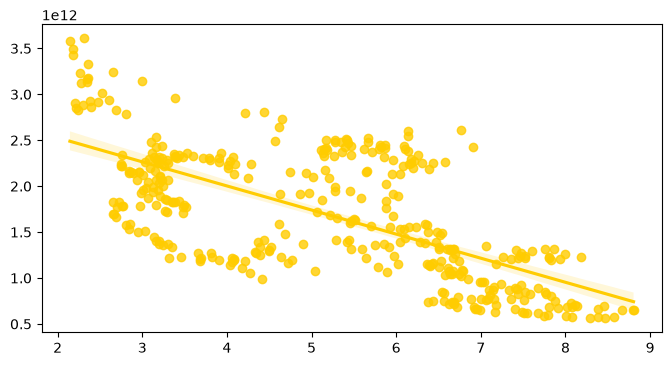

In [6]:
plt.figure(figsize=(8,4))
sns.regplot(x=series2, y=series1, color=color3)
plt.ylabel('')
plt.xlabel('')

In [7]:
print(adfuller(df['roll_pct_chg_US All home sales'].dropna())[1])
print(adfuller(df['roll_pct_chg_MORTGAGE15US'].dropna())[1])
infl_adj_granger_results = grangercausalitytests(df[['roll_pct_chg_US All home sales', 'roll_pct_chg_MORTGAGE15US']].dropna(), maxlag=12)

0.01626137107466826
0.0006405396938962684


C:\Users\illoi\AppData\Local\Temp\ipykernel_16960\1715413175.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  print(adfuller(df['roll_pct_chg_US All home sales'].dropna())[1])
C:\Users\illoi\AppData\Local\Temp\ipykernel_16960\1715413175.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  print(adfuller(df['roll_pct_chg_MORTGAGE15US'].dropna())[1])


,Real Estate - market sales,FEDFUNDS,MORTGAGE15US
Real Estate - market sales,1.000000,-0.369465,-0.636689
FEDFUNDS,-0.369465,1.000000,0.845716
MORTGAGE15US,-0.636689,0.845716,1.000000


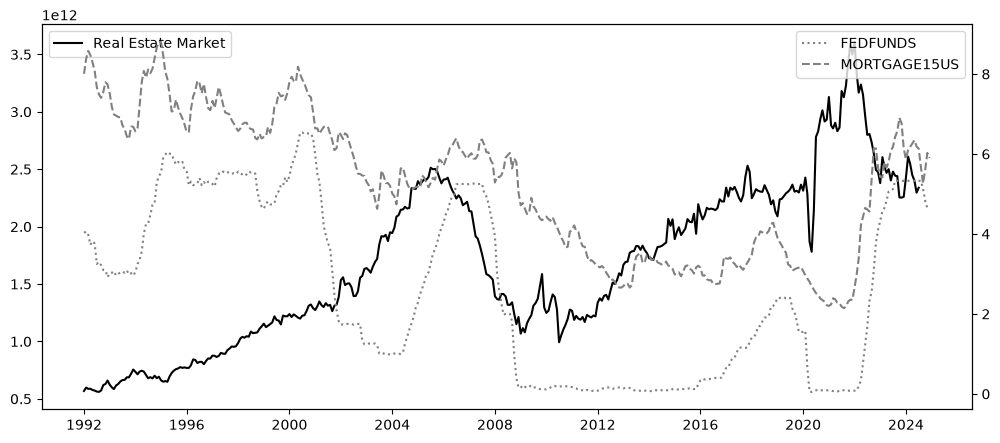

In [8]:
fig, ax1 = plt.subplots()
ax1.plot(df['Real Estate - market sales'], 'black', label='Real Estate Market')
ax1.legend(loc='upper left')
ax2 = ax1.twinx()
ax2.plot(df['FEDFUNDS'], 'grey', label='FEDFUNDS', linestyle=':')
ax2.plot(df['MORTGAGE15US'], 'grey', label='MORTGAGE15US', linestyle='dashed')
ax2.legend(loc='upper right')

df[['Real Estate - market sales', 'FEDFUNDS', 'MORTGAGE15US']].corr()

PearsonRResult(statistic=np.float64(-0.22837746781318014), pvalue=np.float64(4.4091308875281545e-06))

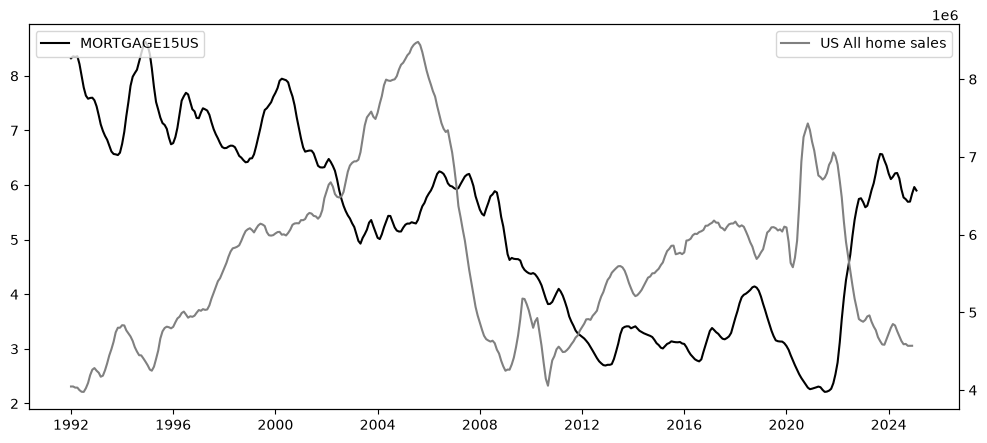

In [9]:
dual_plot_corr(df['MORTGAGE15US'].rolling(window=5, min_periods=1, center=True).mean(), 
               df['US All home sales'].rolling(window=5, min_periods=1, center=True).mean()
              )

PearsonRResult(statistic=np.float64(-0.6334537500855654), pvalue=np.float64(1.7856228670149146e-45))

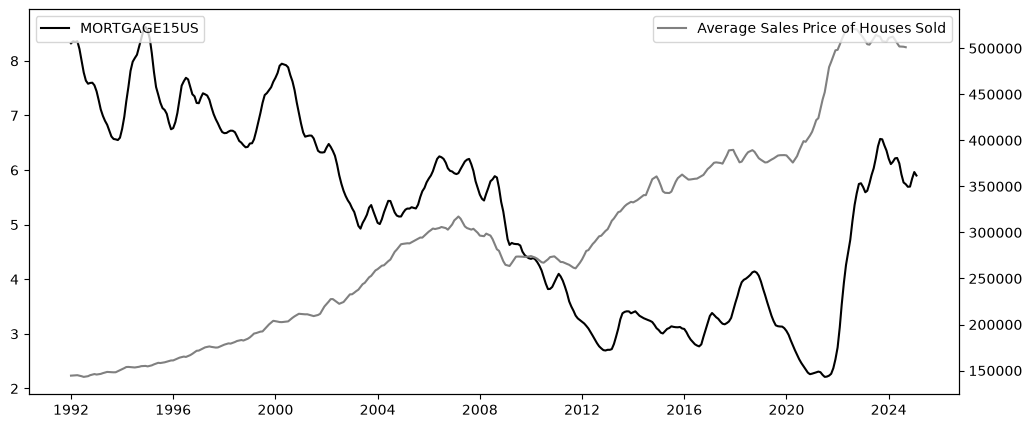

In [10]:
dual_plot_corr(df['MORTGAGE15US'].rolling(window=5, min_periods=1, center=True).mean(), 
               df['Average Sales Price of Houses Sold'].rolling(window=5, min_periods=1, center=True).mean()
              )

3
-0.2372780033112821


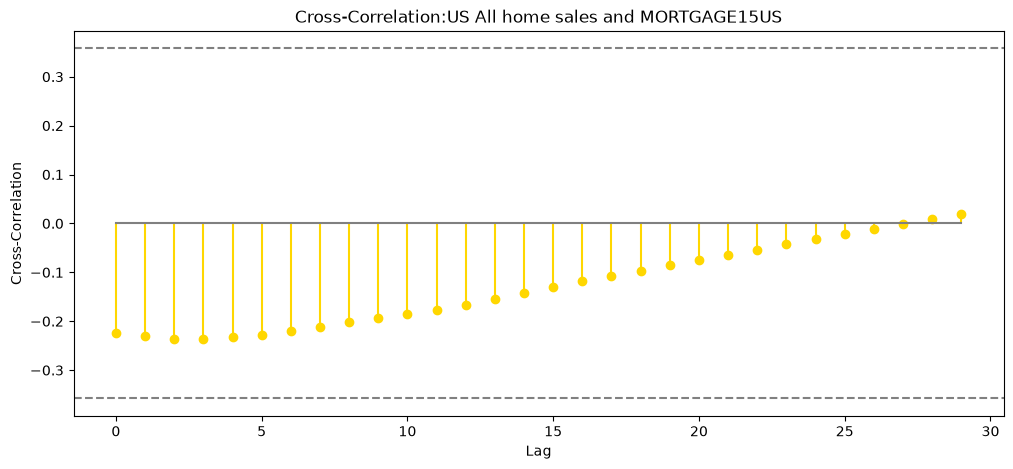

In [11]:
REHS_MORT_ccf = ccf_funct(df['US All home sales'].dropna(), df['MORTGAGE15US'].dropna(), 30)

3
-0.5889580324466692


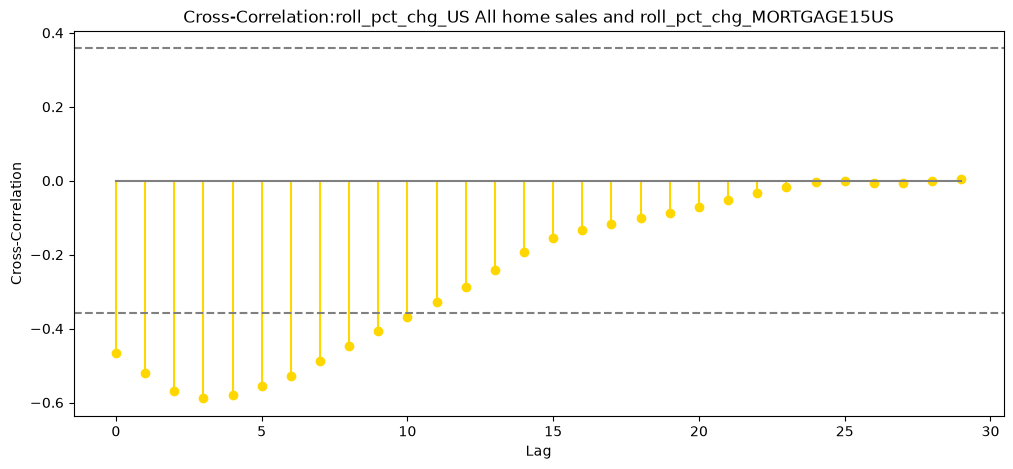

In [12]:
REHS_MORT_ccf = ccf_funct(df['roll_pct_chg_US All home sales'].dropna(), df['roll_pct_chg_MORTGAGE15US'].dropna(), 30)

3
-0.4757367328547086


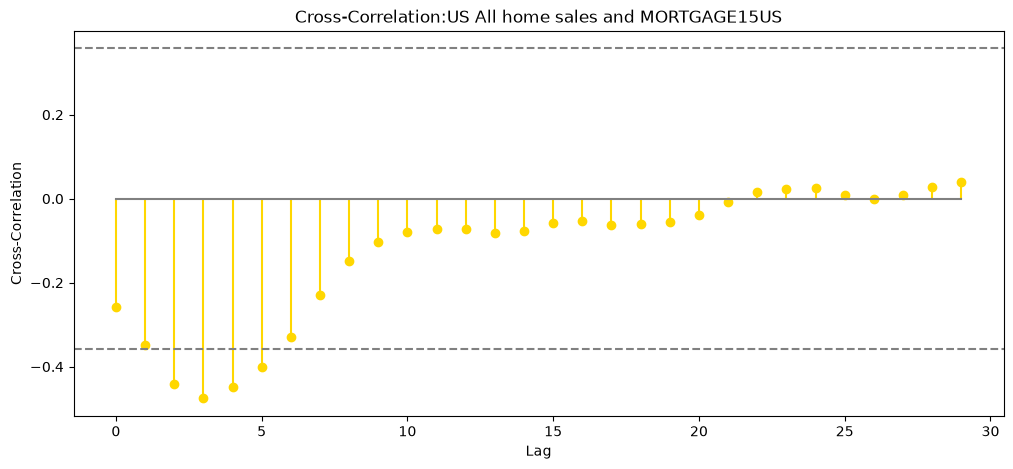

In [13]:
REHS_MORT_ccf = ccf_funct(df['US All home sales'].pct_change(fill_method=None).rolling(window=5, min_periods=1, center=True).mean().dropna(), 
                          df['MORTGAGE15US'].pct_change(fill_method=None).rolling(window=5, min_periods=1, center=True).mean().dropna(), 
                          30
                         )

C:\Users\illoi\AppData\Local\Temp\ipykernel_16960\4083679633.py:8: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  mortgage_US_market_df = pd.concat([shifted_mortgage_series, US_market_home_series], axis=1).dropna()


PearsonRResult(statistic=np.float64(-0.23128073396781634), pvalue=np.float64(3.3018577923419407e-06))

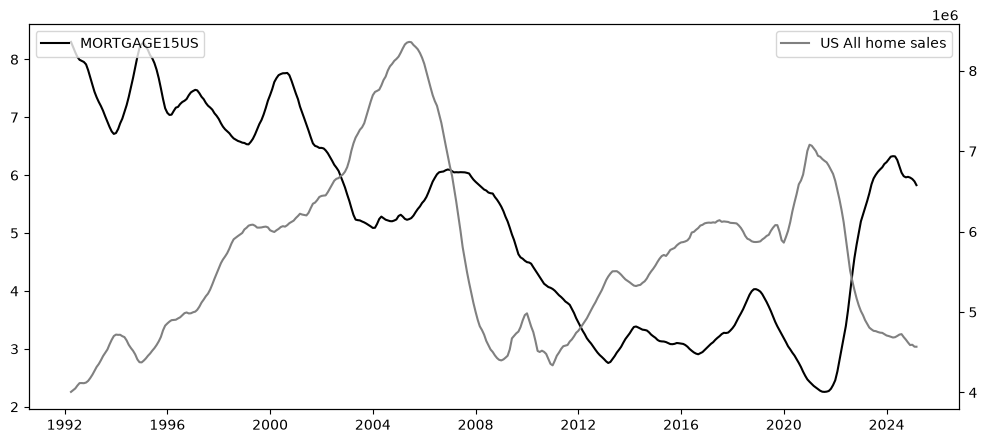

In [14]:
shift = 3
var1='MORTGAGE15US'
var2='US All home sales'

shifted_mortgage_series = df[var1].shift(shift).dropna().rolling(window=12, min_periods=1, center=True).mean()
US_market_home_series = df[var2].rolling(window=12, min_periods=1, center=True).mean()

mortgage_US_market_df = pd.concat([shifted_mortgage_series, US_market_home_series], axis=1).dropna()

dual_plot_corr(mortgage_US_market_df[var1], mortgage_US_market_df[var2])

In [15]:
mortgage_US_market_df.to_csv("C:/Users/illoi/Downloads/data_for_monthly.csv", sep=sep)

19
-0.7467249864743931


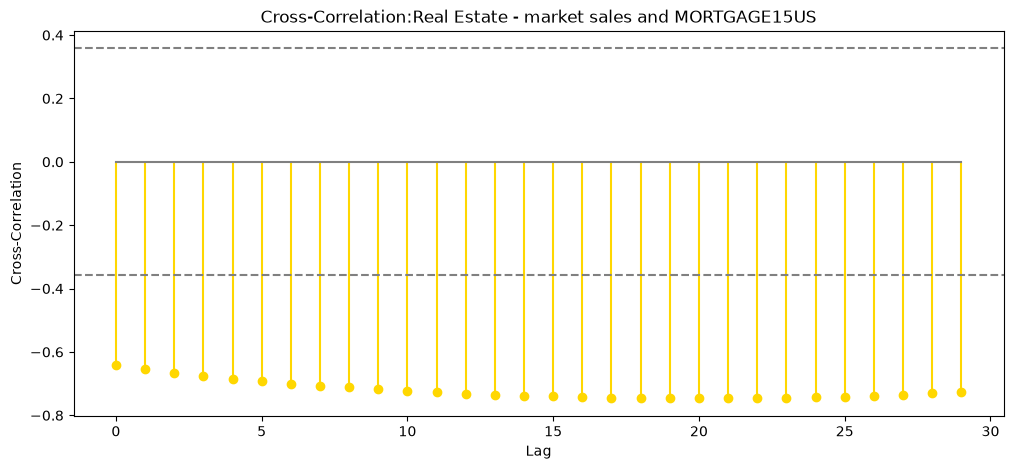

In [16]:
REV_MORT_ccf = ccf_funct(df['Real Estate - market sales'].dropna(), df['MORTGAGE15US'].dropna(), 30)

In [17]:
# cols = ['Real Estate - market sales', 'Y', 'FEDFUNDS', 'MORTGAGE15US']
# (df[cols]/df[cols].max()).plot()

PearsonRResult(statistic=np.float64(-0.3092342702202354), pvalue=np.float64(3.034195408491426e-10))


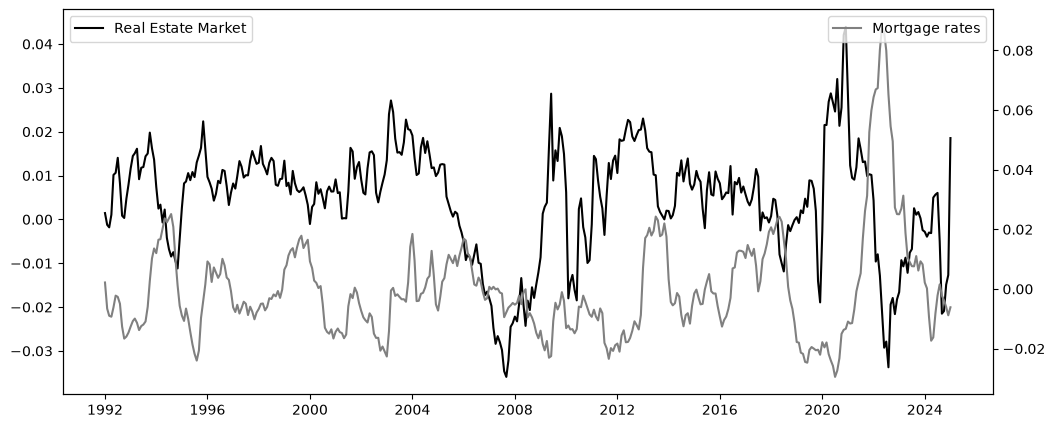

In [18]:
aux_df = df[['roll_pct_chg_Real Estate - market sales', 'roll_pct_chg_MORTGAGE15US']].dropna()

plt_dict_1 = {'Real Estate Market': aux_df['roll_pct_chg_Real Estate - market sales']}
plt_dict_2 = {'Mortgage rates': aux_df['roll_pct_chg_MORTGAGE15US']}
twinplot(plt_dict_1, plt_dict_2)

In [19]:
df[['roll_pct_chg_Real Estate - market sales', 'roll_pct_chg_FEDFUNDS', 'roll_pct_chg_MORTGAGE15US']].corr()

,roll_pct_chg_Real Estate - market sales,roll_pct_chg_FEDFUNDS,roll_pct_chg_MORTGAGE15US
roll_pct_chg_Real Estate - market sales,1.000000,-0.157682,-0.309234
roll_pct_chg_FEDFUNDS,-0.157682,1.000000,0.694963
roll_pct_chg_MORTGAGE15US,-0.309234,0.694963,1.000000


4
-0.5019317739780929


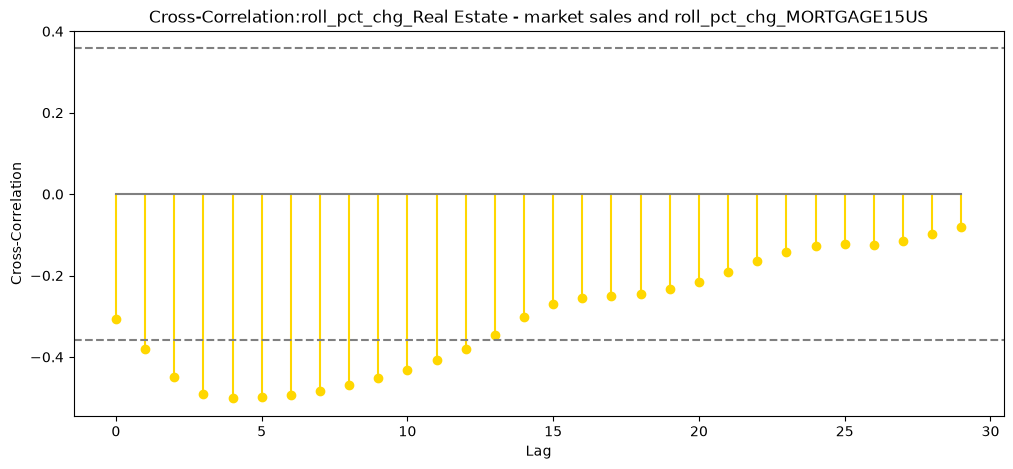

In [20]:
RPCT_REV_MORT_ccf = ccf_funct(df['roll_pct_chg_Real Estate - market sales'].dropna(), df['roll_pct_chg_MORTGAGE15US'].dropna(), 30)

3
-0.43477068557853454


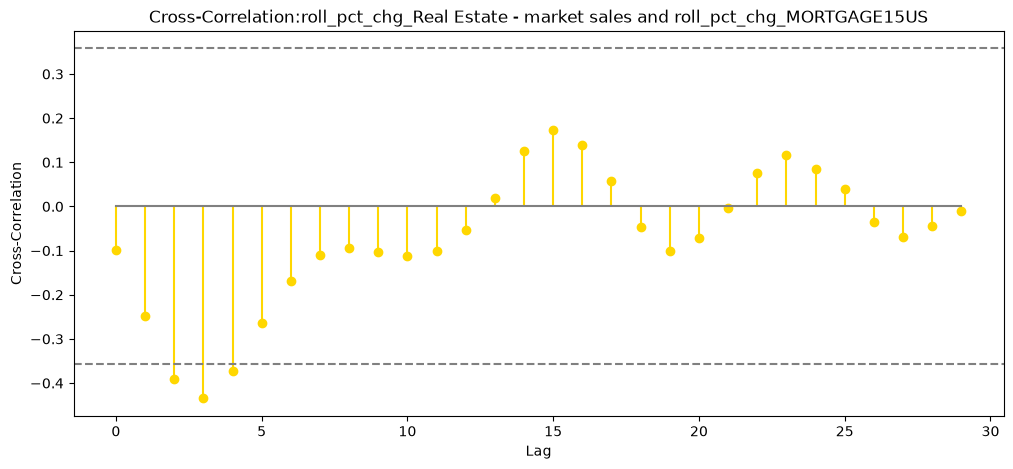

In [21]:
_ = ccf_funct(df['roll_pct_chg_Real Estate - market sales'].diff().dropna().rolling(window=4, min_periods=1, center=True).mean(), 
              df['roll_pct_chg_MORTGAGE15US'].diff().dropna().rolling(window=4, min_periods=1, center=True).mean(), 
              30)

16
-0.31782800067762035


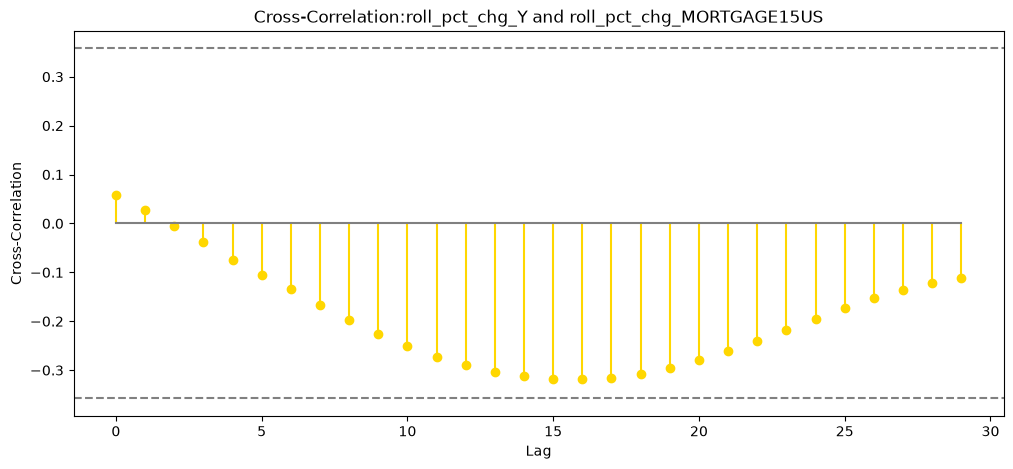

In [22]:
_ = ccf_funct(df['roll_pct_chg_Y'].dropna(), df['roll_pct_chg_MORTGAGE15US'].dropna(), 30)

PearsonRResult(statistic=np.float64(-0.24620519129686352), pvalue=np.float64(7.502832938971069e-07))

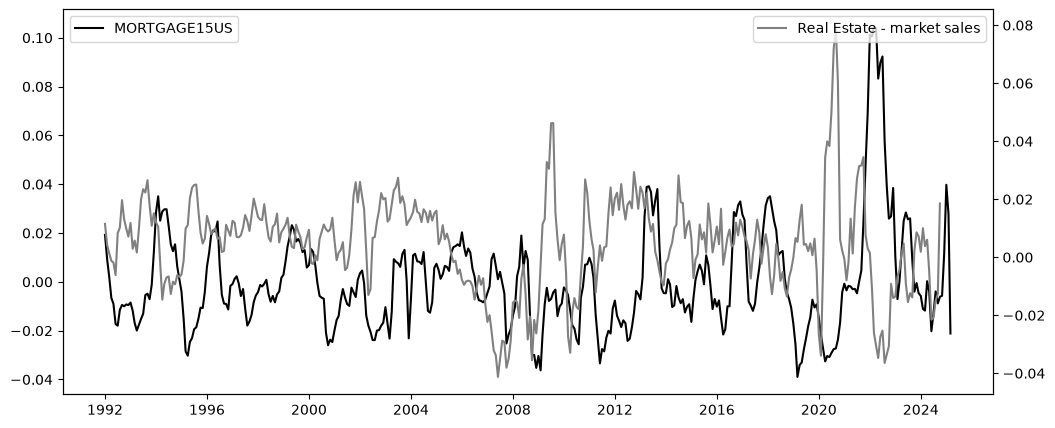

In [23]:
dual_plot_corr(df['MORTGAGE15US'].pct_change(fill_method=None).rolling(window=7, min_periods=1, center=True).mean(), 
               df['Real Estate - market sales'].pct_change(fill_method=None).rolling(window=7, min_periods=1, center=True).mean()
              )

3
-0.47203213041198244


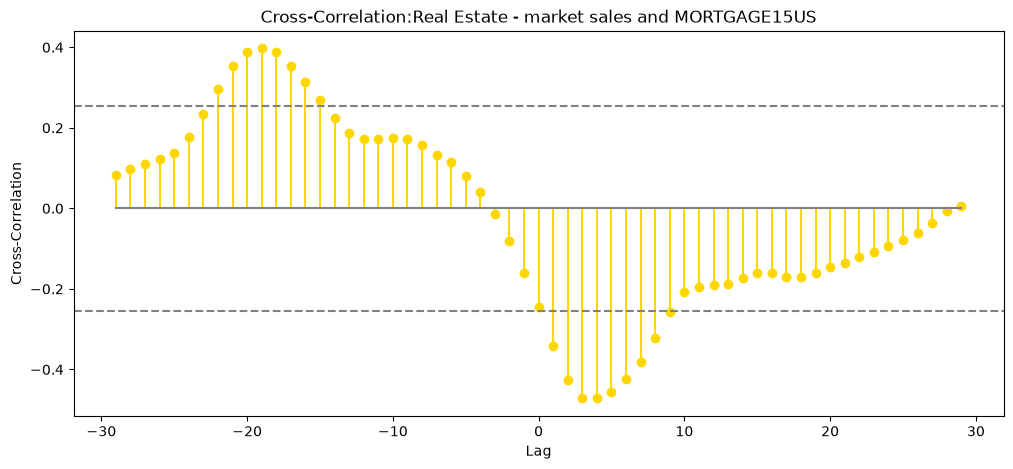

In [24]:
_ = ccf_funct(df['Real Estate - market sales'].pct_change(fill_method=None).rolling(window=7, min_periods=1, center=True).mean().dropna(), 
              df['MORTGAGE15US'].pct_change(fill_method=None).rolling(window=7, min_periods=1, center=True).mean().dropna(), 
              30, both_sides=True
             )

np.float64(-0.2824702841135953)

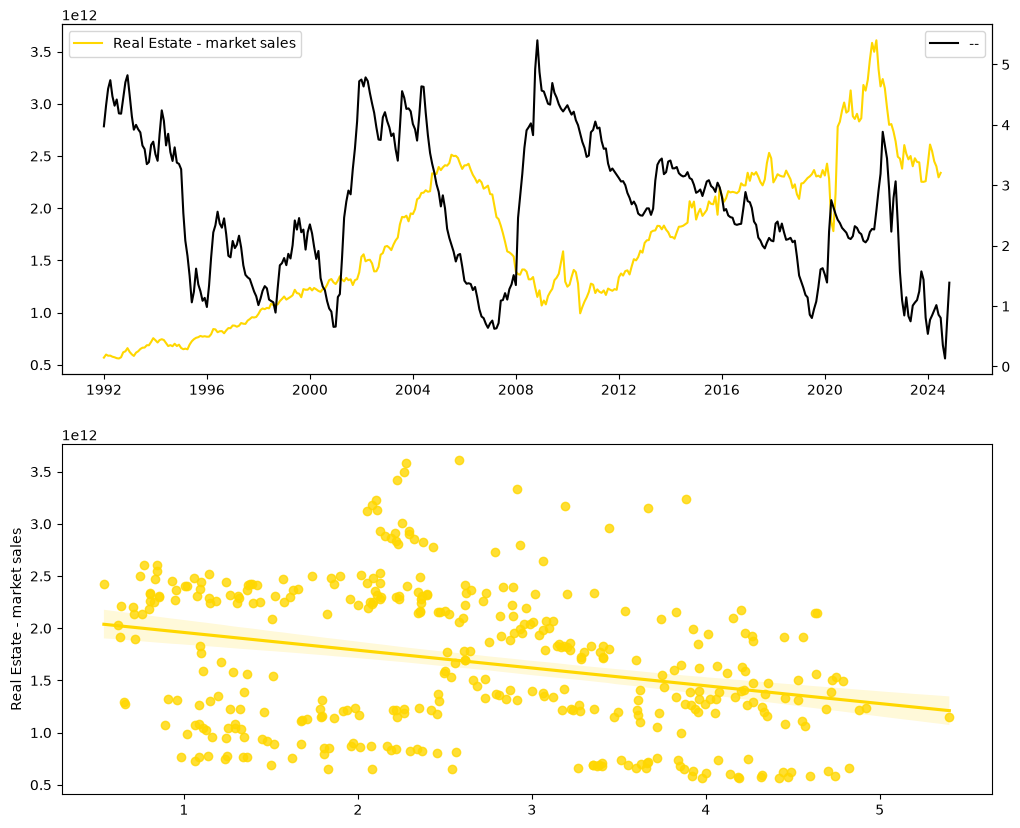

In [25]:
series_rel_plot(df['Real Estate - market sales'], df['MORTGAGE15US'] - df['FEDFUNDS'])

13
-0.30566299967043403


C:\Users\illoi\AppData\Local\Temp\ipykernel_16960\1203680844.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Mortgage_spread'] = df['MORTGAGE15US'] - df['FEDFUNDS']


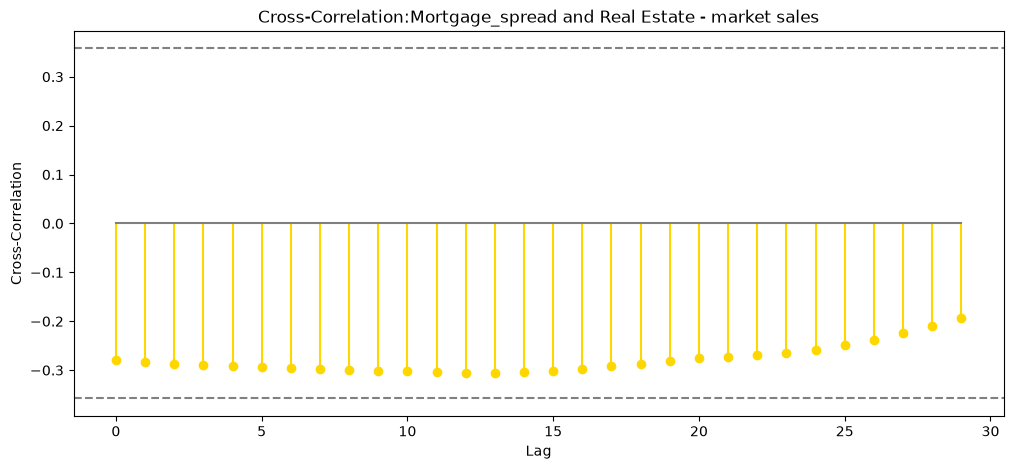

In [26]:
df['Mortgage_spread'] = df['MORTGAGE15US'] - df['FEDFUNDS']
_ = ccf_funct(df['Mortgage_spread'].dropna(), df['Real Estate - market sales'].dropna(), 30)

### Other

PearsonRResult(statistic=np.float64(nan), pvalue=np.float64(nan))


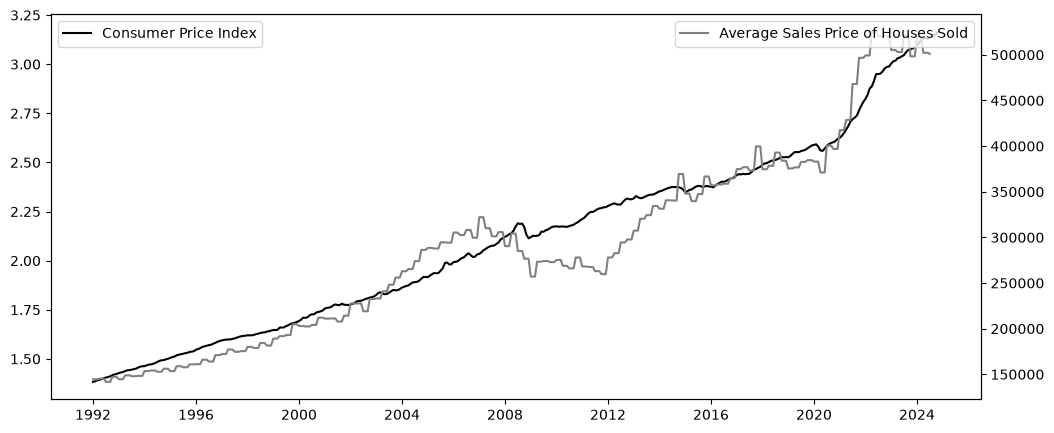

In [27]:
twinplot({'Consumer Price Index': df['Consumer Price Index']}, {'Average Sales Price of Houses Sold':df['Average Sales Price of Houses Sold']})

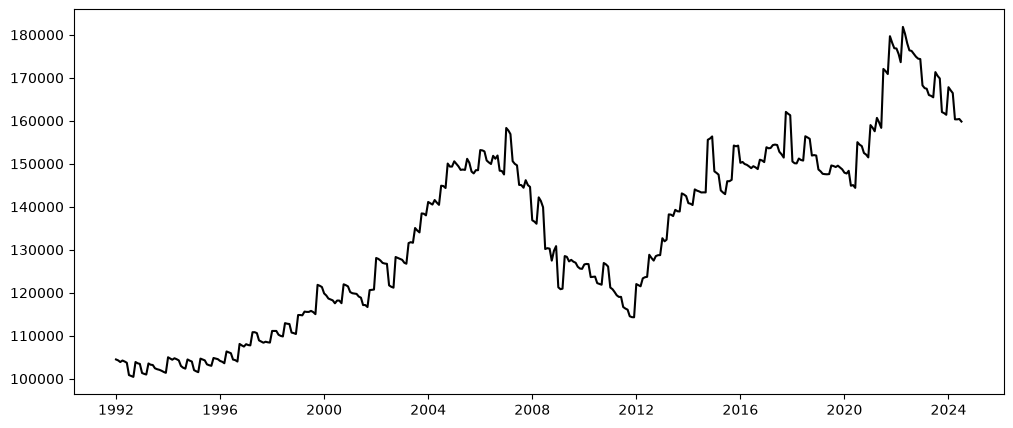

In [28]:
plt.plot(df['Average Sales Price of Houses Sold']/df['Consumer Price Index'], 'k')

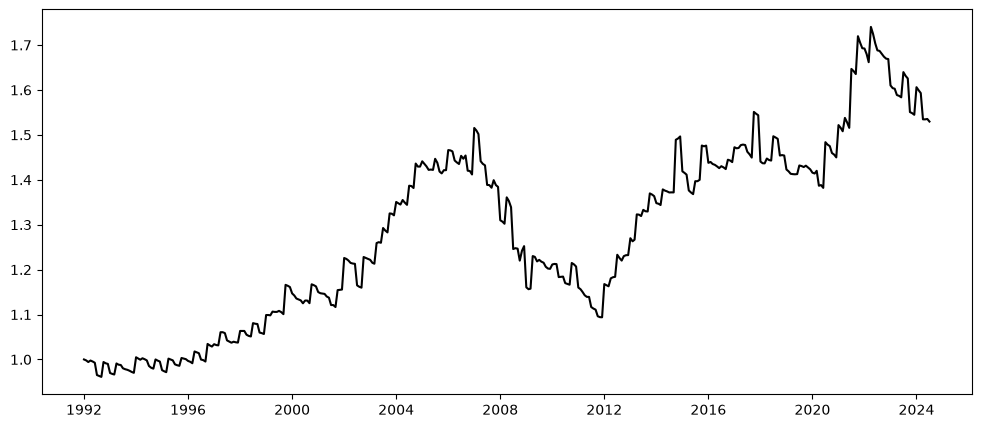

In [29]:
series1 = df['Average Sales Price of Houses Sold'] / df['Average Sales Price of Houses Sold'].iloc[0]
series2 = df['Consumer Price Index'] / df['Consumer Price Index'].iloc[0]
plt.plot(series1/series2, 'k')

### Economic factors

TODO: EXISTING HOUSEHOLDS

<Axes: >

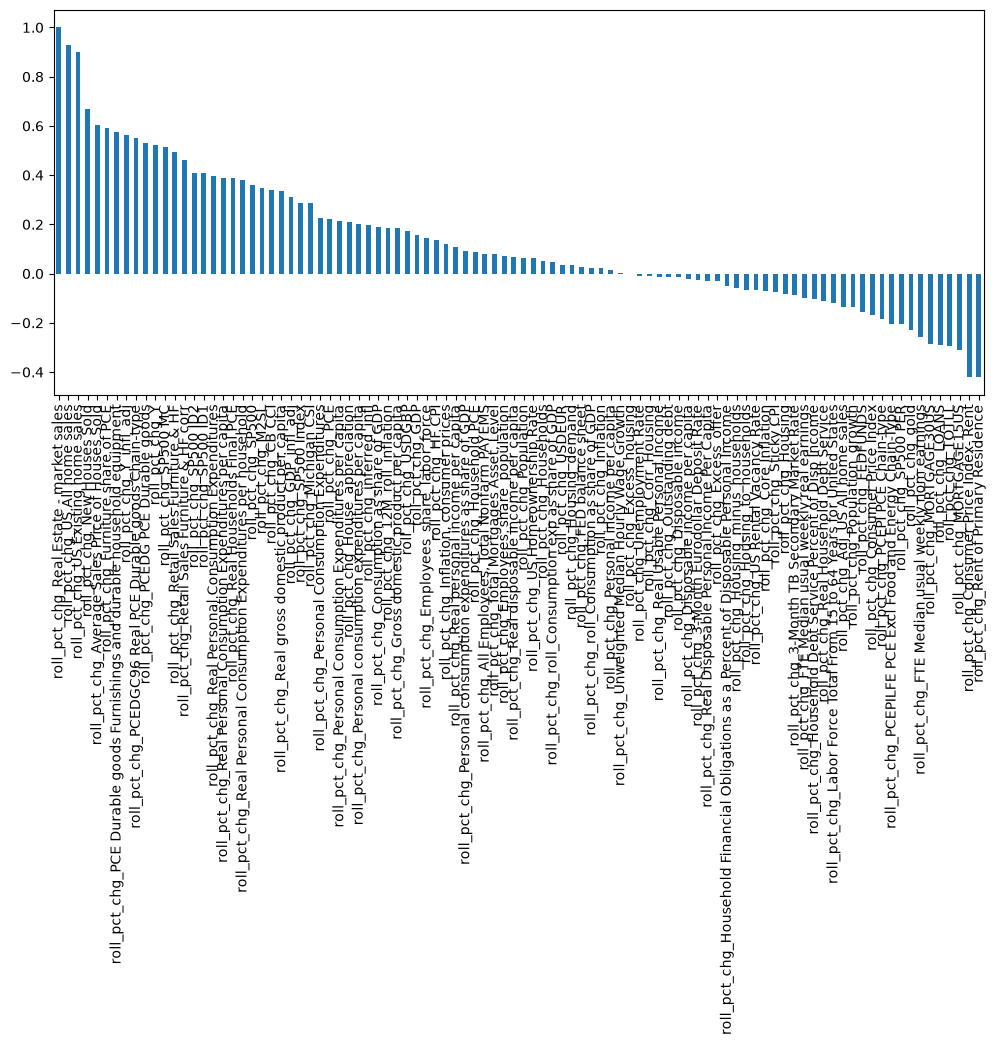

In [32]:
roll_pct_chg_original_columns_ampl = list('roll_pct_chg_' + original_cols)
df[roll_pct_chg_original_columns_ampl].corr()['roll_pct_chg_Real Estate - market sales'].sort_values(ascending=False).plot(kind='bar')

<Axes: >

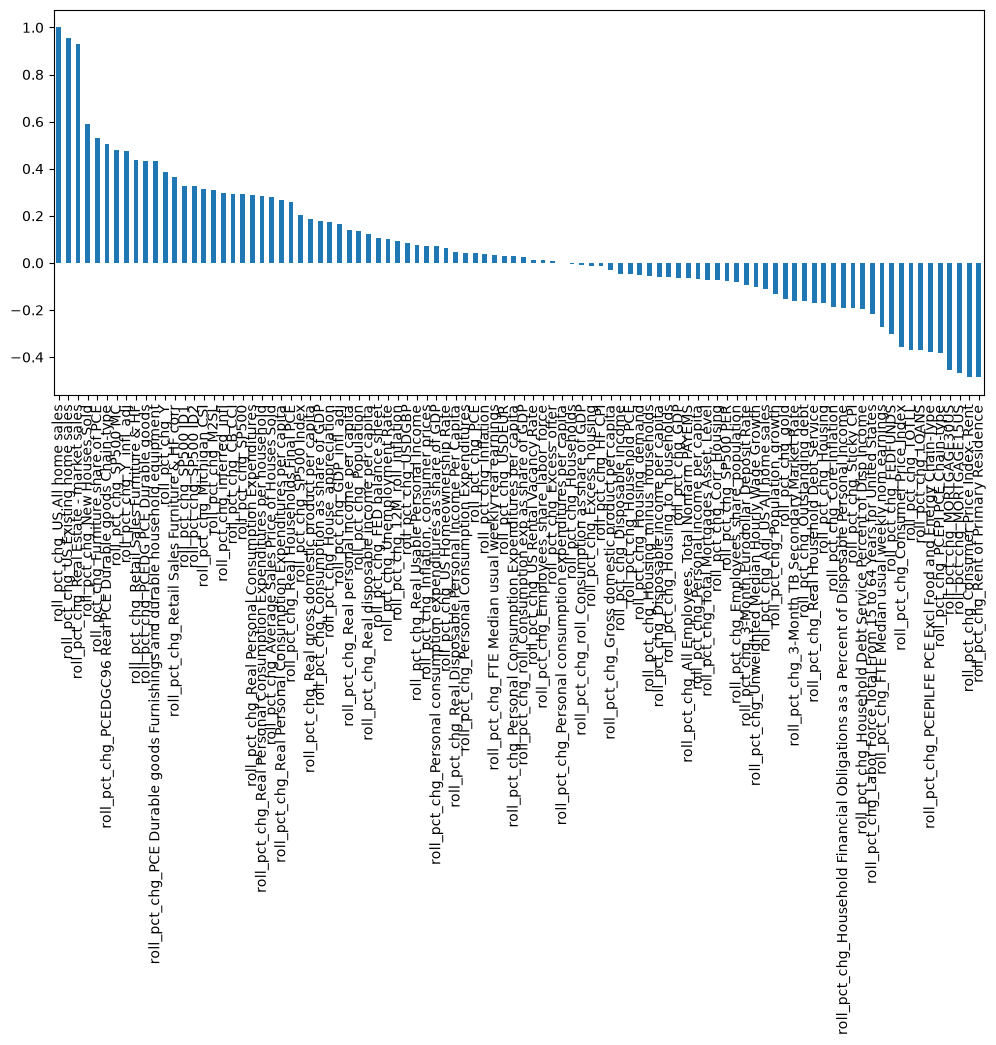

In [33]:
df[roll_pct_chg_original_columns_ampl].corr()['roll_pct_chg_US All home sales'].sort_values(ascending=False).plot(kind='bar')